# Descripción del Dataset

El dataset de **Salary** generalmente contiene dos columnas principales:

- **YearsExperience**: Representa la cantidad de años de experiencia laboral de un individuo en una industria específica. Los valores en esta columna son numéricos y típicamente van desde 1 hasta más de 20 años de experiencia.

- **Salary**: Representa el salario anual en miles de dólares de un individuo con una cantidad específica de años de experiencia.

## Características

- **Tamaño pequeño**: El dataset tiene un tamaño adecuado para realizar pruebas rápidas, pero lo suficientemente grande como para observar patrones de regresión lineal. Generalmente consta de unas 30-50 filas.

- **Distribución lineal**: Existe una relación lineal entre los años de experiencia y el salario. Es decir, a mayor cantidad de años de experiencia, mayor será el salario, aunque con cierta dispersión.


# Paso No.1 Carga del Dataset

Primero, cargamos el dataset que contiene las columnas **YearsExperience** y **Salary**. Este paso es esencial para analizar y visualizar la relación entre los años de experiencia y el salario. Asegúrate de que el archivo del dataset esté disponible en el directorio de trabajo o proporciona la ruta completa al archivo.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [7]:
import pandas as pd

# Cargar el dataset
ruta_dataset = '../../datasets/Dataset_Salario/Salary_dataset.csv'
data = pd.read_csv(ruta_dataset)

# Mostrar las primeras filas del dataset
display(data)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0



# Paso No.2 Definimos las Variables de Estudio

En este paso, seleccionamos las variables principales del dataset que utilizaremos para nuestro análisis. Estas variables son:

- **YearsExperience**: Representa los años de experiencia laboral.
- **Salary**: Representa el salario anual en miles de dólares.

Estas variables serán fundamentales para explorar la relación entre la experiencia y el salario.


In [8]:
# Separar las variables de estudio
X = data[['YearsExperience']]  # Variable independiente
y = data['Salary']  # Variable dependiente

# Mostrar las primeras filas de las variables
display(X.head(), y.head())

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


0    39344.0
1    46206.0
2    37732.0
3    43526.0
4    39892.0
Name: Salary, dtype: float64


# Paso No.3 División de los Datos: 80-20

Hemos dividido el dataset en dos conjuntos principales:

- **Conjunto de Entrenamiento (80%)**: Este conjunto contiene el 80% de los datos y se utiliza para entrenar el modelo de regresión lineal. Es decir, el modelo aprenderá la relación entre los años de experiencia y el salario utilizando estos datos.

- **Conjunto de Prueba (20%)**: Este conjunto contiene el 20% restante de los datos y se utiliza para evaluar el rendimiento del modelo. Nos permite verificar qué tan bien el modelo generaliza a datos no vistos previamente.

La división se realizó de manera aleatoria, asegurando que los datos estén equilibrados en ambos conjuntos.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Paso No.4 Creación del Modelo de Regresión Lineal

En este paso, creamos un modelo de regresión lineal utilizando la clase `LinearRegression` de la biblioteca `scikit-learn`. Este modelo se entrenará con los datos de entrenamiento (`X_train` y `y_train`) para aprender la relación entre los años de experiencia y el salario. Posteriormente, evaluaremos su rendimiento con los datos de prueba.


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# Paso No.5 Gráfica y Evaluación del Modelo

En este paso, graficamos los resultados del modelo de regresión lineal y evaluamos su rendimiento. Esto incluye:

1. **Gráfica de Resultados**: Compararemos los valores reales (`y_test`) con los valores predichos (`y_pred`) para visualizar qué tan bien el modelo se ajusta a los datos.

2. **Evaluación del Modelo**: Calcularemos métricas como el error cuadrático medio (MSE) para cuantificar el rendimiento del modelo.


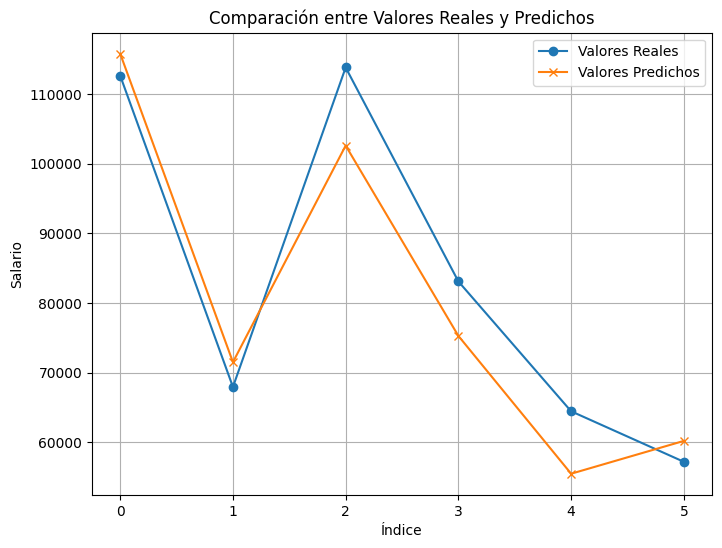

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(y_test.values, label='Valores Reales', marker='o')
plt.plot(y_pred, label='Valores Predichos', marker='x')
plt.title('Comparación entre Valores Reales y Predichos')
plt.xlabel('Índice')
plt.ylabel('Salario')
plt.legend()
plt.grid(True)
plt.show()


# Paso No.6 Evaluación del Modelo con Métricas de Rendimiento

En este paso, evaluamos los resultados del modelo utilizando las siguientes métricas de rendimiento:

- **RMSE (Root Mean Squared Error)**: Raíz cuadrada del error cuadrático medio, que mide la desviación estándar de los errores de predicción.
- **MSE (Mean Squared Error)**: Error cuadrático medio, que mide el promedio de los errores al cuadrado.
- **MAE (Mean Absolute Error)**: Error absoluto medio, que mide el promedio de los errores absolutos.
- **R² (Coeficiente de Determinación)**: Indica qué tan bien el modelo explica la variabilidad de los datos.

Estas métricas nos permitirán cuantificar el rendimiento del modelo y determinar qué tan bien se ajusta a los datos.

In [12]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Crear un DataFrame con las métricas
metricas = pd.DataFrame({
    'Métrica': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Valor': [mse, rmse, mae, r2]
})

# Mostrar la tabla
display(metricas)

,Métrica,Valor
0,MSE,4.983010e+07
1,RMSE,7.059044e+03
2,MAE,6.286454e+03
3,R²,9.024462e-01


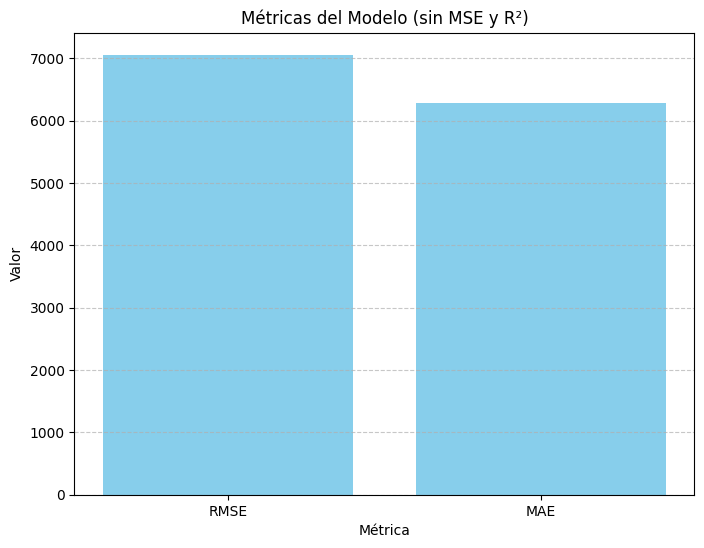

In [14]:
# Filtrar las métricas para excluir 'MSE' y 'R²'
metricas_filtradas = metricas[(metricas['Métrica'] != 'MSE') & (metricas['Métrica'] != 'R²')]

# Crear la gráfica de barras
plt.figure(figsize=(8, 6))
plt.bar(metricas_filtradas['Métrica'], metricas_filtradas['Valor'], color='skyblue')
plt.title('Métricas del Modelo (sin MSE y R²)')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
